# 01 Data Extraction And Audit

This notebook is the data-grounding step for the thesis. It documents what was packaged, how hybrid and paired subsets differ, and why split constraints are strict before any model results are interpreted.

**What this notebook now covers**
- Clean subset accounting (hybrid, paired-labeled, paired-unlabeled)
- Feature-block quality and missingness
- Correlation structure for `fpos` and `fmiss`
- Waveform and ACG morphology shifts across paired families
- Family/sorter heterogeneity maps
- Recording-disjoint and family-held-out protocol diagnostics


In [38]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

CWD = Path.cwd().resolve()
if (CWD / "data" / "raw" / "33000_ROWS.parquet").exists():
    ROOT = CWD
elif (CWD.parent / "data" / "raw" / "33000_ROWS.parquet").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError("Could not locate repository root with data/raw/33000_ROWS.parquet")

DATA_PATH = ROOT / "data" / "raw" / "33000_ROWS.parquet"
MANIFEST_PATH = ROOT / "data" / "frozen_inputs" / "manifest.json"

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Missing frozen manifest at {MANIFEST_PATH}")

fig_dir = ROOT / "figures" / "01_data_extraction_and_audit"
table_dir = ROOT / "tables" / "01_data_extraction_and_audit"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "hybrid": "#24577A",
    "paired_labeled": "#2D8C73",
    "paired_unlabeled": "#D9822B",
    "accent": "#6D3B6A",
    "neutral": "#7A7A7A",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
})


def save_figure(fig, stem: str) -> Path:
    out = fig_dir / f"{stem}.png"
    fig.savefig(out, bbox_inches="tight")
    return out


def save_table(df: pd.DataFrame, stem: str) -> Path:
    out = table_dir / f"{stem}.csv"
    df.to_csv(out, index=False)
    return out


def _paired_family_label(study_set: pd.Series) -> pd.Series:
    return study_set.astype(str).str.replace("PAIRED_", "", regex=False)


manifest = json.loads(MANIFEST_PATH.read_text())
df = pd.read_parquet(DATA_PATH).copy()

df["dataset_kind"] = np.where(df["study_set"].astype(str).str.startswith("PAIRED"), "paired", "hybrid")
df["recording_key"] = df["study_set"].astype(str) + "::" + df["recording_name"].astype(str)
df["is_paired_labeled"] = df["dataset_kind"].eq("paired") & df["match_status"].isin(["matched_best", "well_detected"])
df["is_paired_unlabeled"] = df["dataset_kind"].eq("paired") & ~df["is_paired_labeled"]
df["paired_family"] = np.where(df["dataset_kind"].eq("paired"), _paired_family_label(df["study_set"]), "HYBRID")

np.random.seed(42)


## 0. Feature Distribution Overview (Before Any Modeling)

This section gives a fast visual check of raw feature distributions across hybrid vs paired domains, plus paired-family spread for key morphology descriptors.


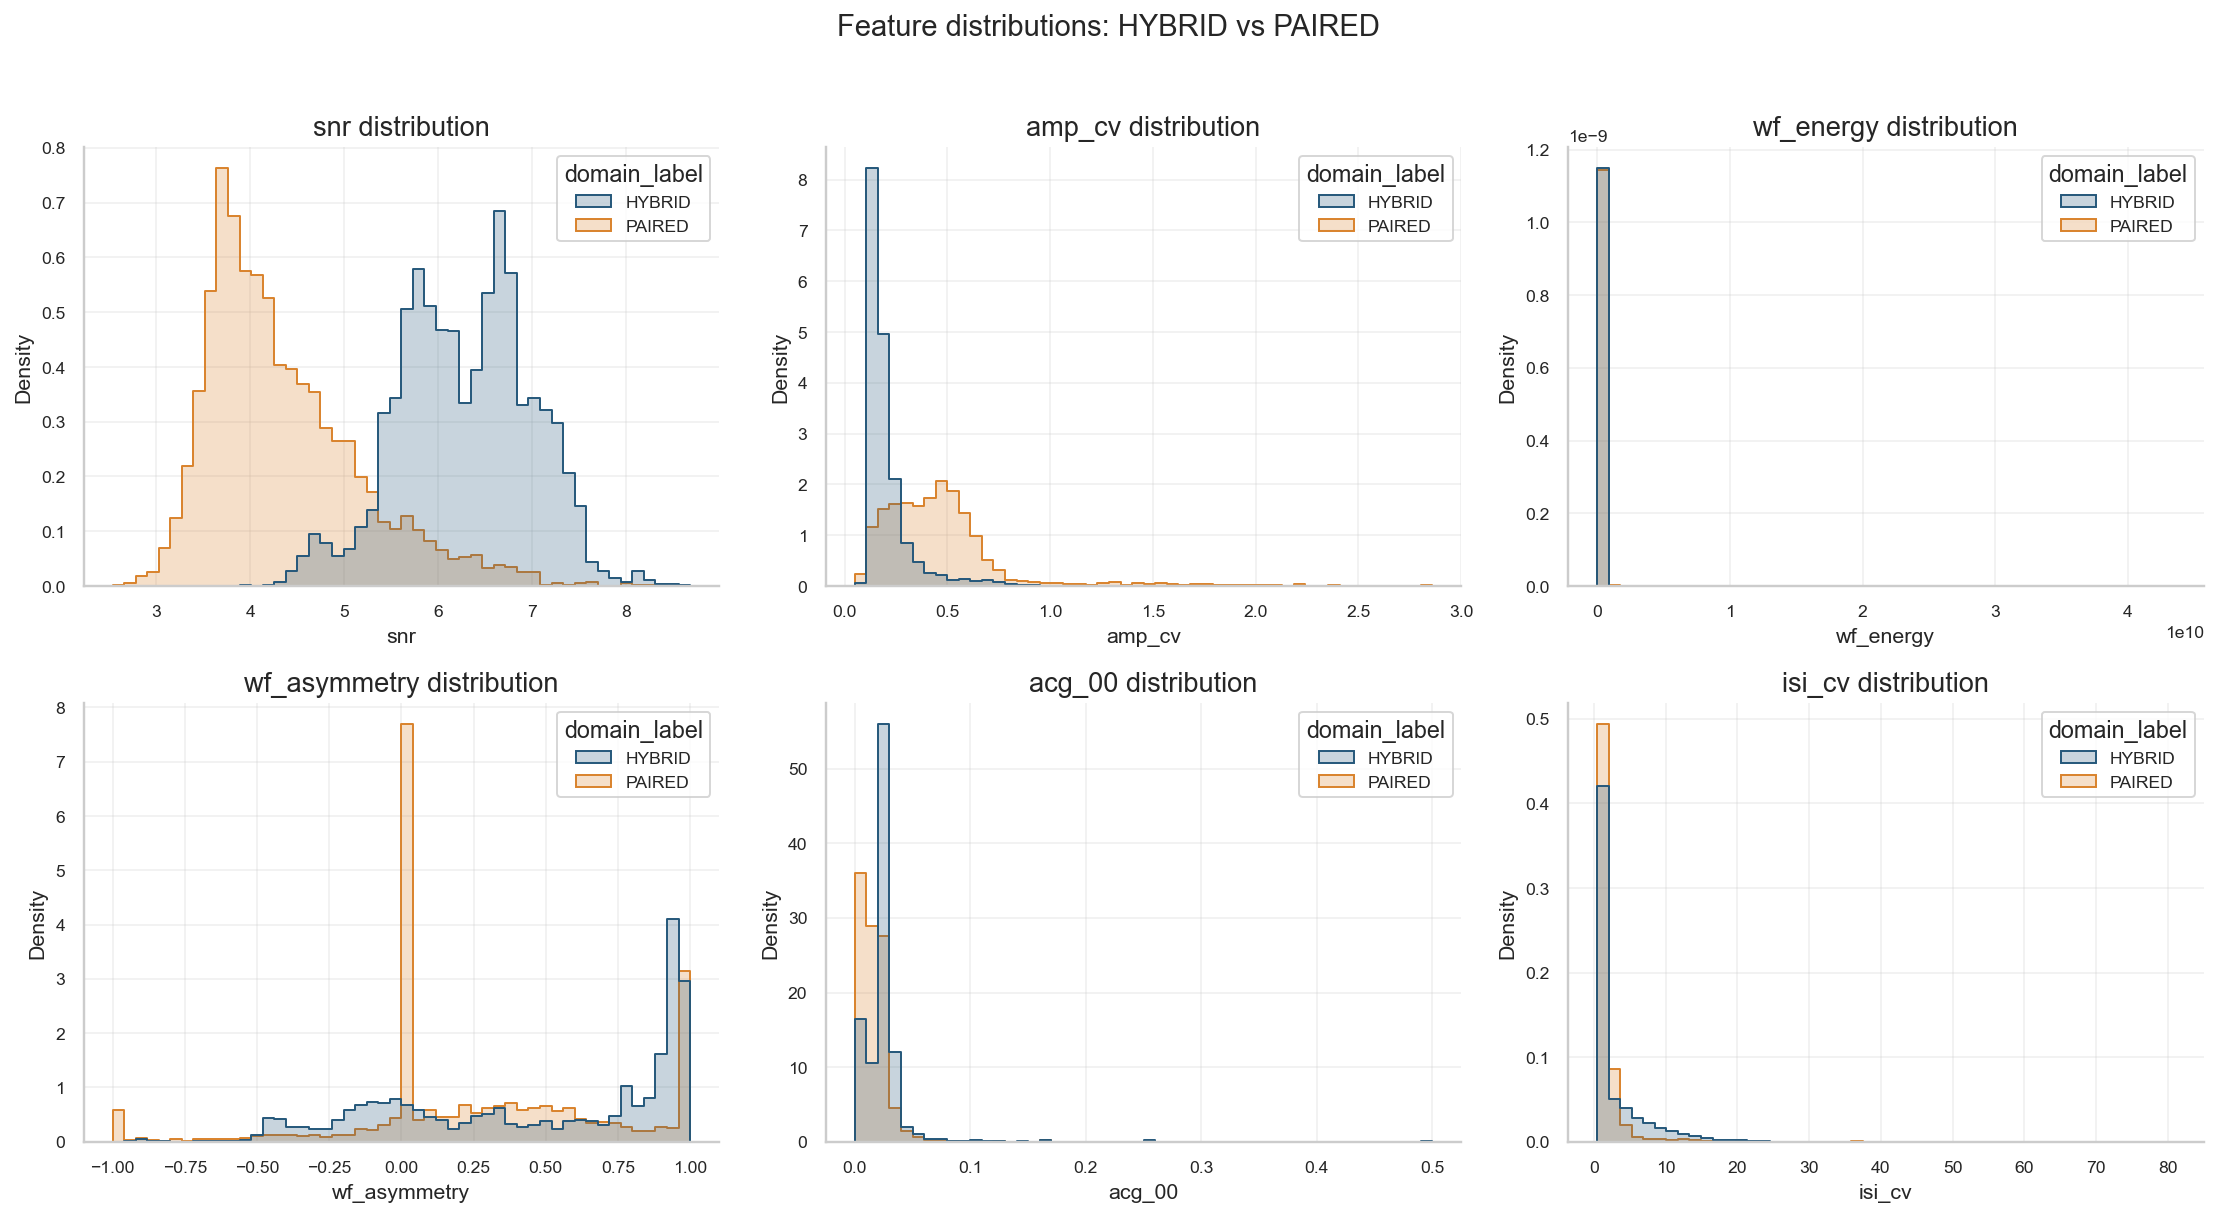

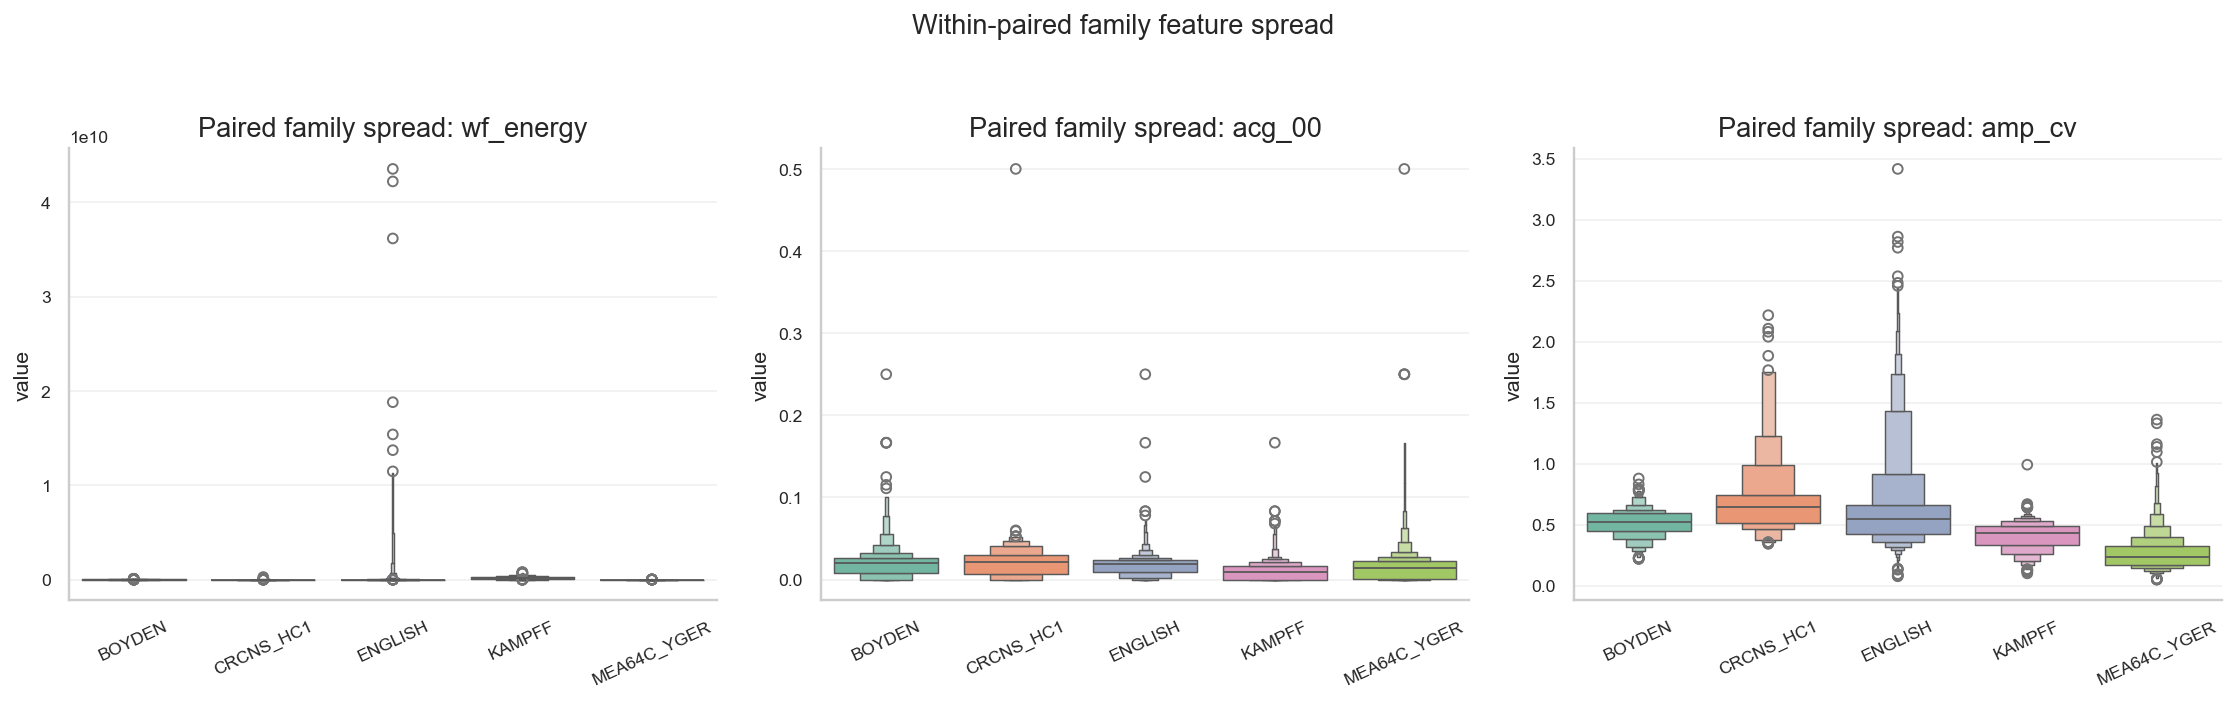

In [39]:
distribution_features = [
    "snr",
    "amp_cv",
    "wf_energy",
    "wf_asymmetry",
    "acg_00",
    "isi_cv",
]
distribution_features = [c for c in distribution_features if c in df.columns]

plot_sample = df.sample(n=min(12000, len(df)), random_state=42).copy()
plot_sample["domain_label"] = np.where(plot_sample["dataset_kind"].eq("hybrid"), "HYBRID", "PAIRED")

dist_fig, dist_axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, feature in zip(dist_axes.ravel(), distribution_features):
    part = plot_sample[[feature, "domain_label"]].dropna()
    sns.histplot(
        data=part,
        x=feature,
        hue="domain_label",
        stat="density",
        common_norm=False,
        bins=50,
        element="step",
        fill=True,
        alpha=0.25,
        palette={"HYBRID": PALETTE["hybrid"], "PAIRED": PALETTE["paired_unlabeled"]},
        ax=ax,
    )
    ax.set_title(f"{feature} distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

for ax in dist_axes.ravel()[len(distribution_features):]:
    ax.axis("off")

dist_fig.suptitle("Feature distributions: HYBRID vs PAIRED", y=1.02, fontsize=15)
dist_fig.tight_layout()
save_figure(dist_fig, "feature_distributions_hybrid_vs_paired")
plt.show()

paired_plot = df[df["dataset_kind"].eq("paired")].copy()
family_features = [c for c in ["wf_energy", "acg_00", "amp_cv"] if c in paired_plot.columns]
family_long = paired_plot.melt(id_vars=["paired_family"], value_vars=family_features, var_name="feature", value_name="value").dropna()

fig, axes = plt.subplots(1, len(family_features), figsize=(5.4 * len(family_features), 4.8), sharex=False)
if len(family_features) == 1:
    axes = [axes]
for ax, feature in zip(axes, family_features):
    part = family_long[family_long["feature"].eq(feature)]
    sns.boxenplot(data=part, x="paired_family", y="value", hue="paired_family", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"Paired family spread: {feature}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Within-paired family feature spread", y=1.04, fontsize=14)
fig.tight_layout()
save_figure(fig, "feature_distributions_paired_families")
plt.show()


### Graph Interpretation: Feature Distribution Overview

**What we learn**
- Several core descriptors (SNR, amplitude variability, waveform energy/asymmetry, early ACG bins, ISI variability) are not identically distributed between `HYBRID` and `PAIRED` domains.
- The paired-family boxen plots show that the paired domain is not a single compact target: family-level spread is substantial even before modeling.

**How this sets up domain-shift hypotheses**
- Supports a **covariate-shift hypothesis**: feature marginals move from hybrid to paired.
- Supports a **heterogeneous-target hypothesis**: paired families represent different sub-regimes, so adaptation quality should vary by family.
- Motivates transfer methods that can absorb shift while preserving family-specific signal structure.


## 1. Packaged Data And Operational Subsets

The tables and first figure establish the exact composition used by every downstream benchmark: one large labeled hybrid source, a very small paired-labeled adaptation set, and a large paired-unlabeled structural pool.


In [40]:
dataset_summary = {
    "total_rows": int(len(df)),
    "total_recordings": int(df["recording_key"].nunique()),
    "total_sorters": int(df["sorter_name"].nunique()),
    "hybrid_rows": int(df["dataset_kind"].eq("hybrid").sum()),
    "paired_rows": int(df["dataset_kind"].eq("paired").sum()),
    "paired_labeled_rows": int(df["is_paired_labeled"].sum()),
    "paired_unlabeled_rows": int(df["is_paired_unlabeled"].sum()),
    "fpos_non_missing": int(df["fpos"].notna().sum()),
    "fmiss_non_missing": int(df["fmiss"].notna().sum()),
}

partition_table = pd.DataFrame([
    {"subset": "full", "rows": len(df), "recordings": df["recording_key"].nunique(), "families": df["study_set"].nunique()},
    {
        "subset": "hybrid_labeled",
        "rows": int(df["dataset_kind"].eq("hybrid").sum()),
        "recordings": df.loc[df["dataset_kind"].eq("hybrid"), "recording_key"].nunique(),
        "families": df.loc[df["dataset_kind"].eq("hybrid"), "study_set"].nunique(),
    },
    {
        "subset": "paired_total",
        "rows": int(df["dataset_kind"].eq("paired").sum()),
        "recordings": df.loc[df["dataset_kind"].eq("paired"), "recording_key"].nunique(),
        "families": df.loc[df["dataset_kind"].eq("paired"), "study_set"].nunique(),
    },
    {
        "subset": "paired_labeled",
        "rows": int(df["is_paired_labeled"].sum()),
        "recordings": df.loc[df["is_paired_labeled"], "recording_key"].nunique(),
        "families": df.loc[df["is_paired_labeled"], "study_set"].nunique(),
    },
    {
        "subset": "paired_unlabeled",
        "rows": int(df["is_paired_unlabeled"].sum()),
        "recordings": df.loc[df["is_paired_unlabeled"], "recording_key"].nunique(),
        "families": df.loc[df["is_paired_unlabeled"], "study_set"].nunique(),
    },
])

target_missingness = pd.DataFrame([
    {
        "target": target,
        "non_missing_rows": int(df[target].notna().sum()),
        "missing_rows": int(df[target].isna().sum()),
        "missing_fraction": float(df[target].isna().mean()),
    }
    for target in ["fpos", "fmiss", "accuracy"]
])

family_coverage = (
    df[df["dataset_kind"].eq("paired")]
    .groupby("paired_family", as_index=False)
    .agg(
        rows=("row_uid", "size"),
        recordings=("recording_key", "nunique"),
        sorters=("sorter_name", "nunique"),
        labeled_rows=("is_paired_labeled", "sum"),
    )
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)
family_coverage["labeled_rate"] = family_coverage["labeled_rows"] / family_coverage["rows"]

manifest_table = pd.DataFrame(manifest.items(), columns=["artifact_group", "path"])

display(pd.DataFrame(dataset_summary.items(), columns=["summary_item", "value"]))
display(partition_table)
display(target_missingness)
display(family_coverage)
display(manifest_table)

save_table(pd.DataFrame(dataset_summary.items(), columns=["summary_item", "value"]), "dataset_summary")
save_table(partition_table, "dataset_partition_table")
save_table(target_missingness, "target_missingness")
save_table(family_coverage, "paired_family_coverage")
save_table(manifest_table, "frozen_manifest")


,summary_item,value
0,total_rows,33206
1,total_recordings,61
2,total_sorters,9
3,hybrid_rows,24224
4,paired_rows,8982
5,paired_labeled_rows,207
6,paired_unlabeled_rows,8775
7,fpos_non_missing,33206
8,fmiss_non_missing,18660


,subset,rows,recordings,families
0,full,33206,61,6
1,hybrid_labeled,24224,30,1
2,paired_total,8982,31,5
3,paired_labeled,207,29,5
4,paired_unlabeled,8775,31,5


,target,non_missing_rows,missing_rows,missing_fraction
0,fpos,33206,0,0.000000
1,fmiss,18660,14546,0.438053
2,accuracy,33206,0,0.000000


,paired_family,rows,recordings,sorters,labeled_rows,labeled_rate
0,ENGLISH,3151,15,7,71,0.022533
1,MEA64C_YGER,2997,4,9,36,0.012012
2,KAMPFF,1743,4,8,35,0.020080
3,BOYDEN,907,4,8,43,0.047409
4,CRCNS_HC1,184,4,8,22,0.119565


,artifact_group,path
0,frozen_inputs_root,/Users/paulruiz/Documents/Predicting_Good_Unit...
1,legacy_final_holdout_results,benchmarks/legacy_final_holdout_results.csv
2,ssl_metrics,benchmarks/ssl_metrics.csv
3,mmd_metrics,benchmarks/mmd_metrics.csv
4,workbench_r2_metrics,benchmarks/workbench_r2_metrics.csv
5,workbench_r2_predictions,benchmarks/workbench_r2_predictions.csv
6,fpos_backend_metrics,benchmarks/fpos_backend_metrics.csv
7,fpos_backend_predictions,benchmarks/fpos_backend_predictions.csv
8,fpos_family_robustness_metrics,benchmarks/fpos_family_robustness_metrics.csv
9,fpos_family_robustness_predictions,benchmarks/fpos_family_robustness_predictions.csv


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/01_data_extraction_and_audit/frozen_manifest.csv')

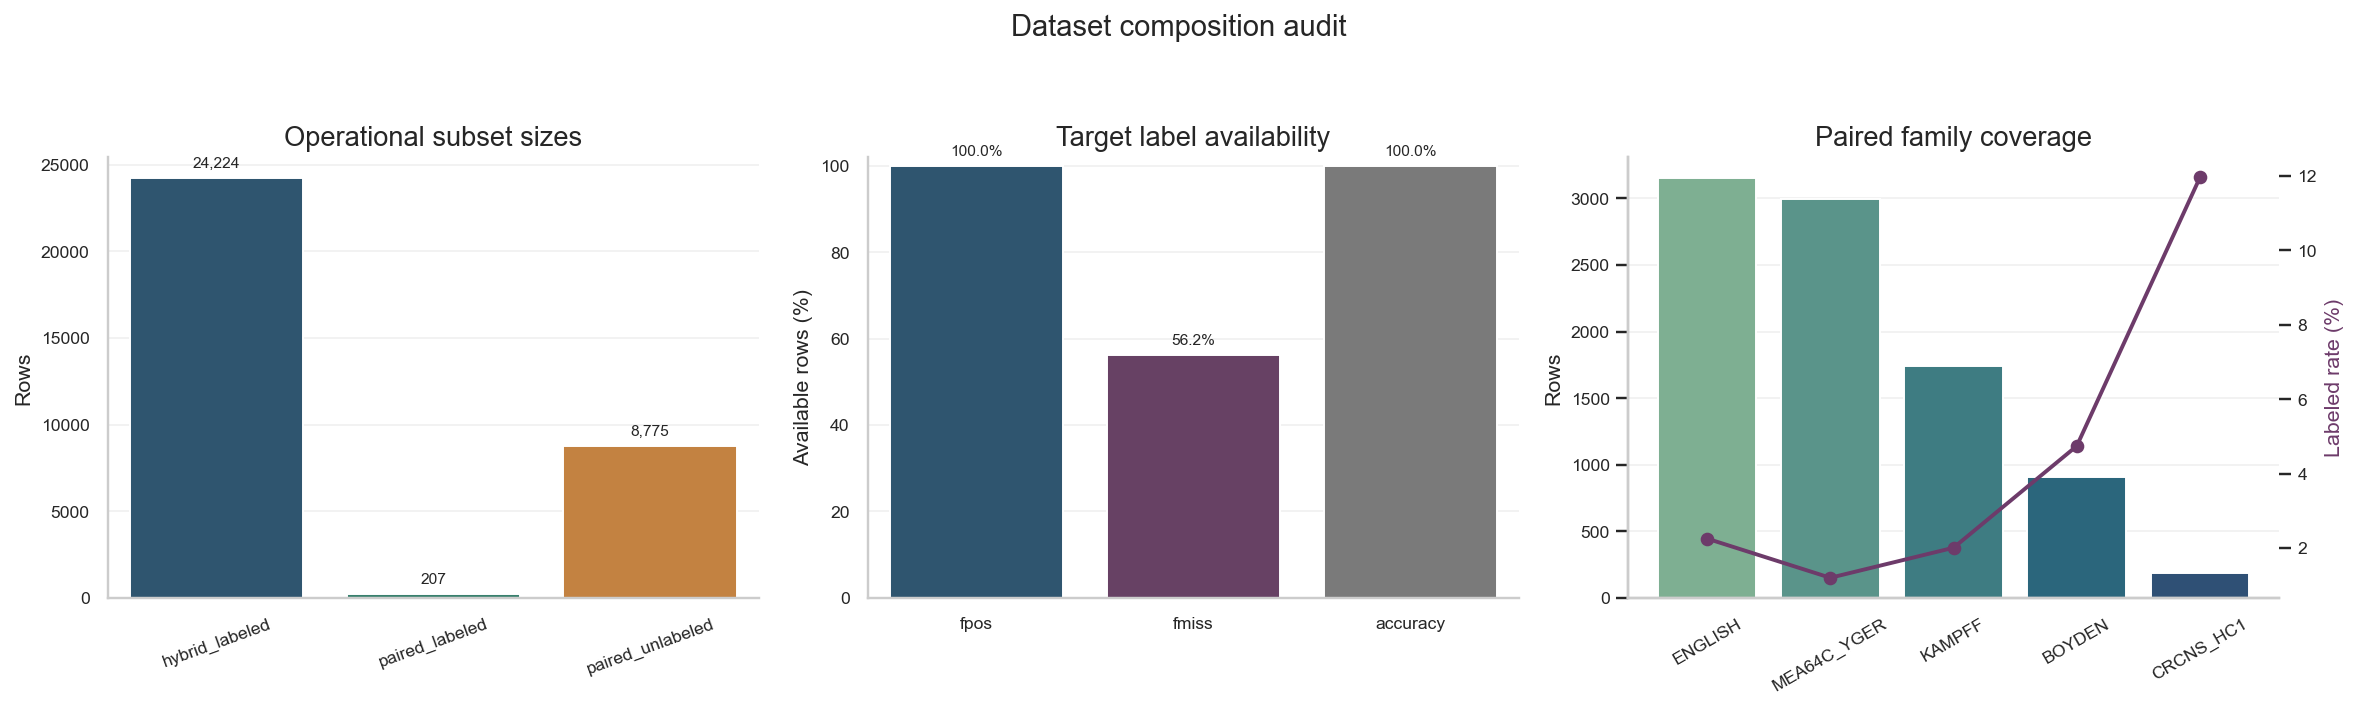

In [41]:
subset_plot = partition_table[partition_table["subset"].isin(["hybrid_labeled", "paired_labeled", "paired_unlabeled"])].copy()
subset_plot["subset"] = pd.Categorical(
    subset_plot["subset"],
    categories=["hybrid_labeled", "paired_labeled", "paired_unlabeled"],
    ordered=True,
)

target_availability = target_missingness.copy()
target_availability["availability_pct"] = 100.0 * target_availability["non_missing_rows"] / len(df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.barplot(
    data=subset_plot,
    x="subset",
    y="rows",
    hue="subset",
    palette={
        "hybrid_labeled": PALETTE["hybrid"],
        "paired_labeled": PALETTE["paired_labeled"],
        "paired_unlabeled": PALETTE["paired_unlabeled"],
    },
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Operational subset sizes")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=20)
for patch in axes[0].patches:
    y = patch.get_height()
    axes[0].annotate(f"{int(y):,}", (patch.get_x() + patch.get_width() / 2, y), ha="center", va="bottom", fontsize=8, xytext=(0, 4), textcoords="offset points")

sns.barplot(
    data=target_availability,
    x="target",
    y="availability_pct",
    hue="target",
    palette={"fpos": PALETTE["hybrid"], "fmiss": PALETTE["accent"], "accuracy": PALETTE["neutral"]},
    legend=False,
    ax=axes[1],
)
axes[1].set_ylim(0, 102)
axes[1].set_title("Target label availability")
axes[1].set_xlabel("")
axes[1].set_ylabel("Available rows (%)")
for patch in axes[1].patches:
    y = patch.get_height()
    axes[1].annotate(f"{y:.1f}%", (patch.get_x() + patch.get_width() / 2, y), ha="center", va="bottom", fontsize=8, xytext=(0, 4), textcoords="offset points")

family_plot = family_coverage.sort_values("rows", ascending=False)
ax2 = axes[2]
ax2b = ax2.twinx()
sns.barplot(data=family_plot, x="paired_family", y="rows", hue="paired_family", palette="crest", legend=False, ax=ax2)
ax2b.plot(np.arange(len(family_plot)), family_plot["labeled_rate"].values * 100.0, color=PALETTE["accent"], marker="o", linewidth=2)
ax2.set_title("Paired family coverage")
ax2.set_xlabel("")
ax2.set_ylabel("Rows")
ax2b.set_ylabel("Labeled rate (%)", color=PALETTE["accent"])
ax2.tick_params(axis="x", rotation=30)
ax2b.grid(False)

fig.suptitle("Dataset composition audit", y=1.05, fontsize=15)
fig.tight_layout()
save_figure(fig, "dataset_composition_audit")
plt.show()


### Graph Interpretation: Dataset Composition Audit

**What we learn**
- The adaptation regime is strongly imbalanced: many hybrid labeled rows, very few paired labeled rows, and a large paired unlabeled pool.
- Labeled support differs by paired family, so supervision is uneven across target sub-domains.
- `fmiss` has fewer valid targets because it depends on ground-truth matching (`fn`/`recall` must exist). Rows marked `unmatched` and most `false_positive` rows do not have that reference, so `fmiss` is undefined there.

**How this sets up domain-shift hypotheses**
- Predicts that naive supervised target-only models will underperform due to sample scarcity.
- Justifies transfer + conservative unlabeled usage as the main strategy.
- Suggests that family-aware evaluation is required, because adaptation data density differs by family.
- Implies that `fmiss` is a harder transfer target not only because of shift, but also because usable supervision is structurally reduced.


## 2. Feature Blocks And Correlation Structure

This section separates waveform bins, ACG bins, amplitude features, ISI features, SpikeInterface quality features, and recording-level context. It then quantifies which features are most associated with `fpos` and `fmiss` inside the paired-labeled adaptation set.


,feature_block,feature_count,mean_missing_pct
2,acg_bins,40,0.000000
0,waveform_bins,30,0.000000
3,amplitude,23,0.097154
1,waveform_shape,21,2.374929
5,spikeinterface,15,14.251039
6,recording_context,6,0.000000
4,isi,5,0.000000


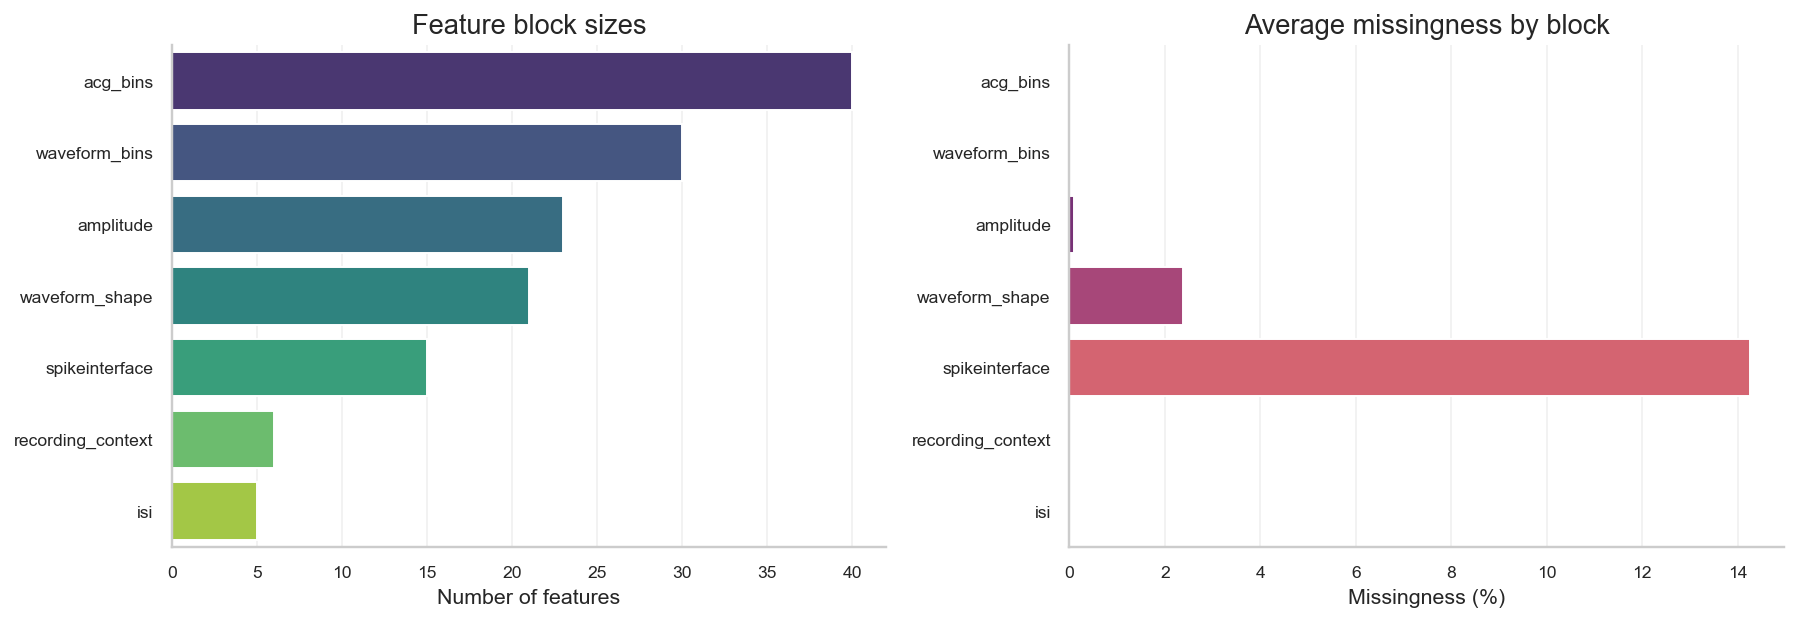

In [42]:
waveform_cols = [c for c in df.columns if c.startswith("wf_")]
waveform_bin_cols = [c for c in df.columns if c.startswith("wf_bin_")]
waveform_shape_cols = [c for c in waveform_cols if c not in waveform_bin_cols]
acg_cols = [c for c in df.columns if c.startswith("acg_")]
amp_cols = [c for c in df.columns if c.startswith("amp_")]
isi_cols = [c for c in df.columns if c.startswith("isi_")]
si_cols = [c for c in df.columns if c.startswith("si_")]
recording_cols = [c for c in df.columns if c.startswith("rec_")]

feature_blocks = {
    "waveform_bins": waveform_bin_cols,
    "waveform_shape": waveform_shape_cols,
    "acg_bins": acg_cols,
    "amplitude": amp_cols,
    "isi": isi_cols,
    "spikeinterface": si_cols,
    "recording_context": recording_cols,
}

feature_inventory = pd.DataFrame([
    {
        "feature_block": name,
        "feature_count": len(cols),
        "mean_missing_pct": float(df[cols].isna().mean().mean() * 100.0) if cols else np.nan,
    }
    for name, cols in feature_blocks.items()
]).sort_values("feature_count", ascending=False)

display(feature_inventory)
save_table(feature_inventory, "feature_inventory")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.barplot(data=feature_inventory, y="feature_block", x="feature_count", hue="feature_block", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Feature block sizes")
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel("")

sns.barplot(data=feature_inventory, y="feature_block", x="mean_missing_pct", hue="feature_block", palette="magma", legend=False, ax=axes[1])
axes[1].set_title("Average missingness by block")
axes[1].set_xlabel("Missingness (%)")
axes[1].set_ylabel("")

fig.tight_layout()
save_figure(fig, "feature_block_inventory")
plt.show()


### Graph Interpretation: Feature Block Inventory

**What we learn**
- Waveform and ACG blocks are high-dimensional and therefore likely to dominate representation geometry.
- Missingness differs by block (for example, waveform-shape and SpikeInterface subsets), which changes effective information content by row/domain.

**How this sets up domain-shift hypotheses**
- Domain shift is not only about means; it can also come from **block reliability differences**.
- Feature filtering, robust preprocessing, and representation-aware modeling are likely necessary under cross-domain transfer.


,target,feature,abs_corr
0,fpos,amp_bin_cv_mean,0.516066
1,fpos,spread_weighted_um,0.470360
2,fpos,spread_um,0.417384
3,fpos,amp_cv,0.414813
4,fpos,si_drift_ptp,0.406263
5,fpos,si_amplitude_cv_median,0.405794
6,fpos,amp_p5,0.393240
7,fpos,si_drift_std,0.388722
8,fpos,peak_to_trough_uv,0.380874
9,fpos,si_drift_mad,0.360690


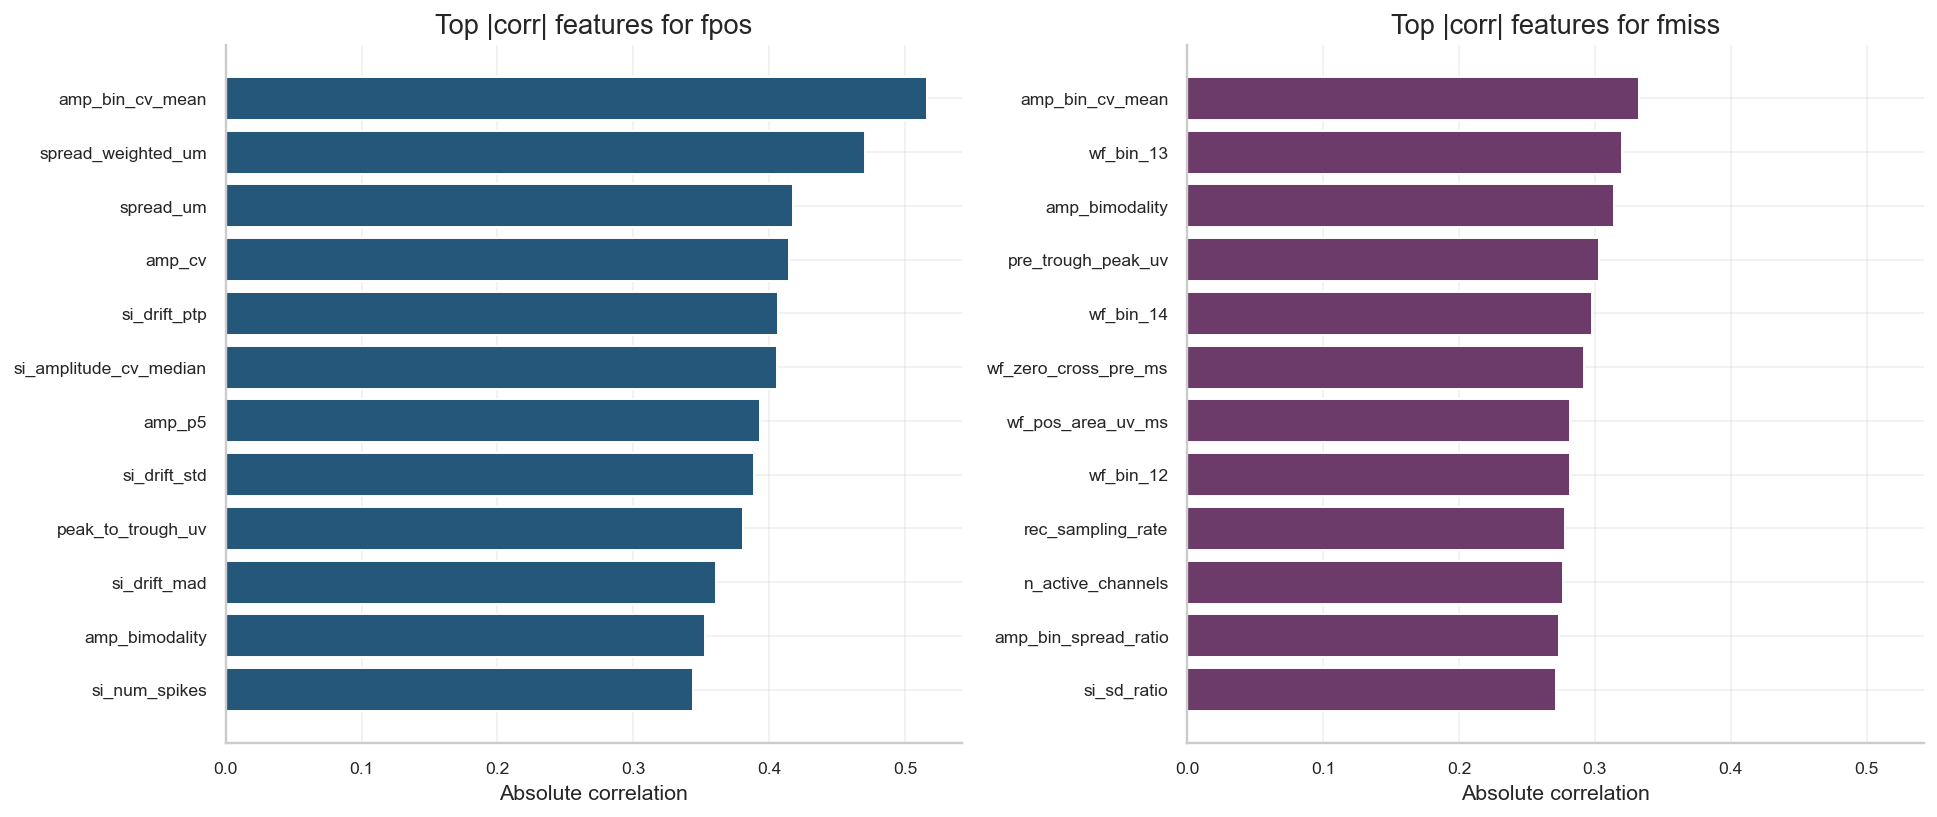

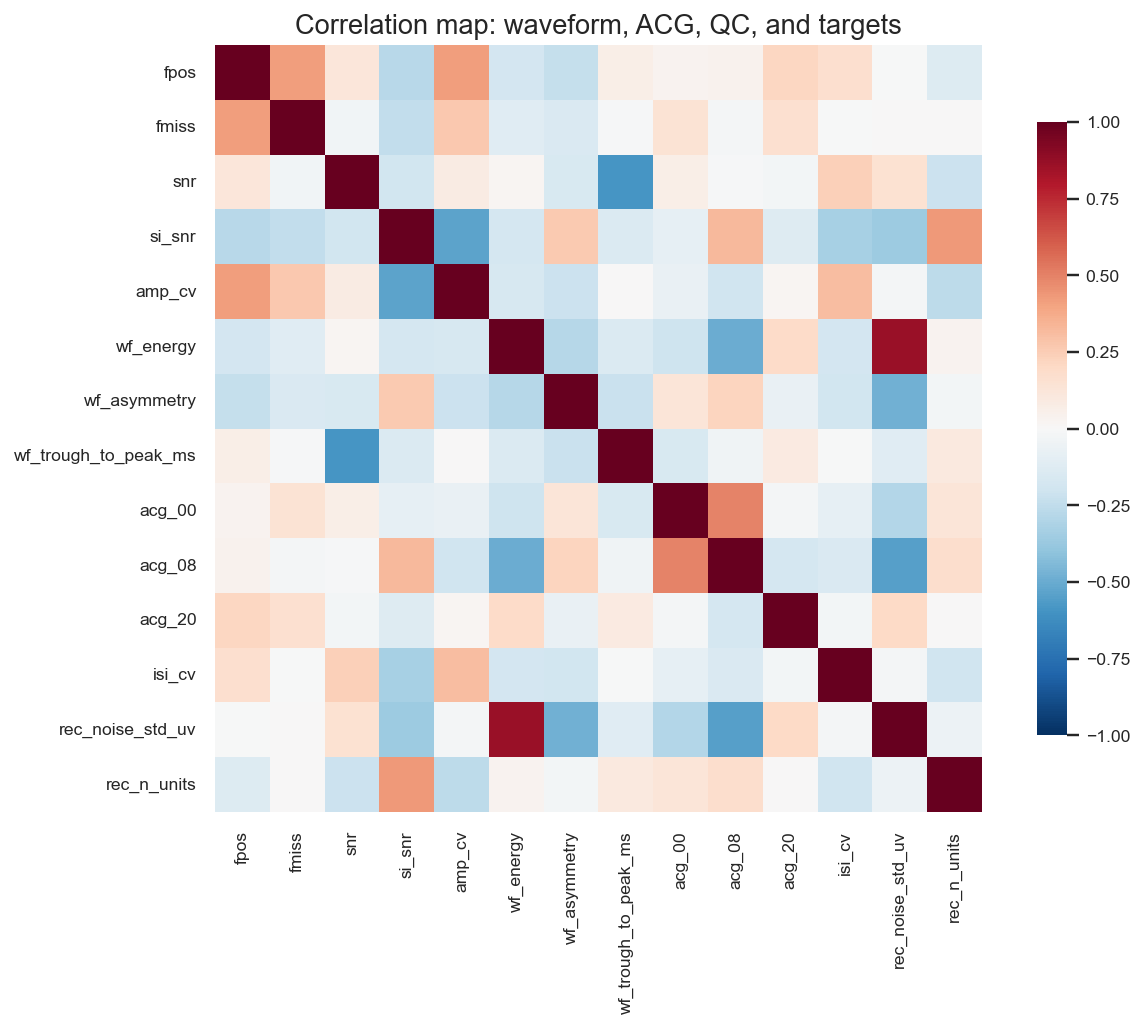

In [43]:
paired_labeled = df[df["is_paired_labeled"]].copy()

exclude_cols = {
    "fpos", "fmiss", "accuracy", "tp", "fp", "fn", "precision", "recall", "agreement_score", "num_gt", "num_tested"
}
numeric_candidates = [c for c in paired_labeled.select_dtypes(include="number").columns if c not in exclude_cols]

corr_frame = paired_labeled[numeric_candidates + ["fpos", "fmiss"]].corr(numeric_only=True)

def top_target_correlations(target: str, top_n: int = 12) -> pd.DataFrame:
    top = (
        corr_frame[target]
        .drop(labels=["fpos", "fmiss"], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
        .rename("abs_corr")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    top.insert(0, "target", target)
    return top

corr_top_fpos = top_target_correlations("fpos", top_n=12)
corr_top_fmiss = top_target_correlations("fmiss", top_n=12)
corr_top = pd.concat([corr_top_fpos, corr_top_fmiss], ignore_index=True)

display(corr_top)
save_table(corr_top, "top_feature_correlations")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, target, color in [
    (axes[0], "fpos", PALETTE["hybrid"]),
    (axes[1], "fmiss", PALETTE["accent"]),
]:
    part = corr_top[corr_top["target"].eq(target)].sort_values("abs_corr", ascending=True)
    ax.barh(part["feature"], part["abs_corr"], color=color)
    ax.set_title(f"Top |corr| features for {target}")
    ax.set_xlabel("Absolute correlation")
    ax.set_ylabel("")

fig.tight_layout()
save_figure(fig, "top_target_correlations")
plt.show()

curated_features = [
    "fpos",
    "fmiss",
    "snr",
    "si_snr",
    "amp_cv",
    "wf_energy",
    "wf_asymmetry",
    "wf_trough_to_peak_ms",
    "acg_00",
    "acg_08",
    "acg_20",
    "isi_cv",
    "rec_noise_std_uv",
    "rec_n_units",
]
curated_features = [c for c in curated_features if c in paired_labeled.columns]

curated_corr = paired_labeled[curated_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(curated_corr, cmap="RdBu_r", center=0.0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation map: waveform, ACG, QC, and targets")
fig.tight_layout()
save_figure(fig, "curated_correlation_heatmap")
plt.show()


### Graph Interpretation: Correlation Structure

**What we learn**
- `fpos` and `fmiss` are not driven by the same top features; their strongest correlates differ in both identity and relative strength.
- The curated heatmap shows coupled but non-identical relationships between targets and morphology/QC/context variables.

**How this sets up domain-shift hypotheses**
- Supports a **target-asymmetry hypothesis**: transfer behavior for `fpos` and `fmiss` should diverge.
- Implies that successful adaptation may require target-specific feature emphasis and diagnostics.


## 3. ACG/Waveform Morphology Across Hybrid And Paired Families

For clarity, this section now produces **one figure per paired family**. Each figure has two aligned panels:
- waveform-bin profile (HYBRID vs that family)
- ACG-bin profile (HYBRID vs that family)


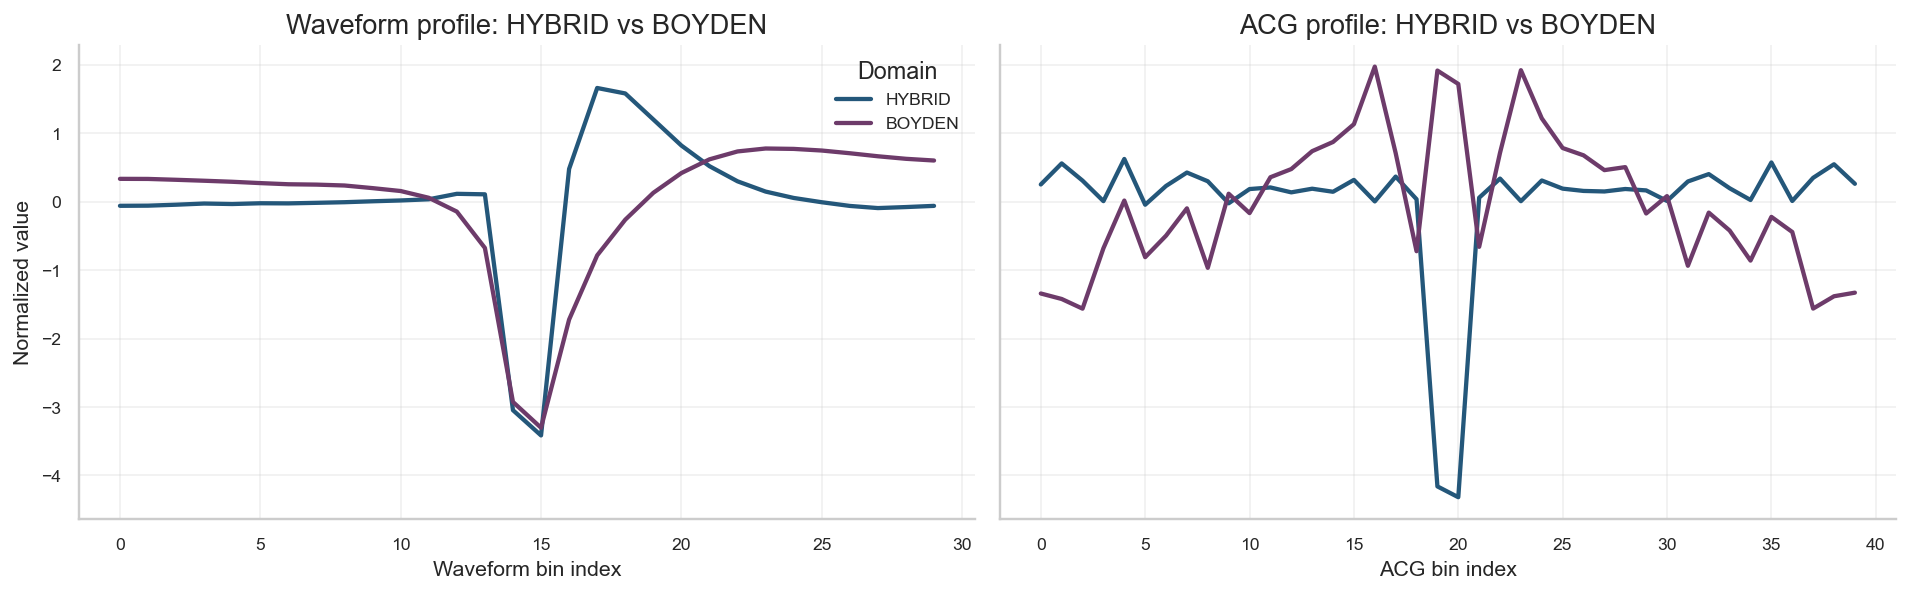

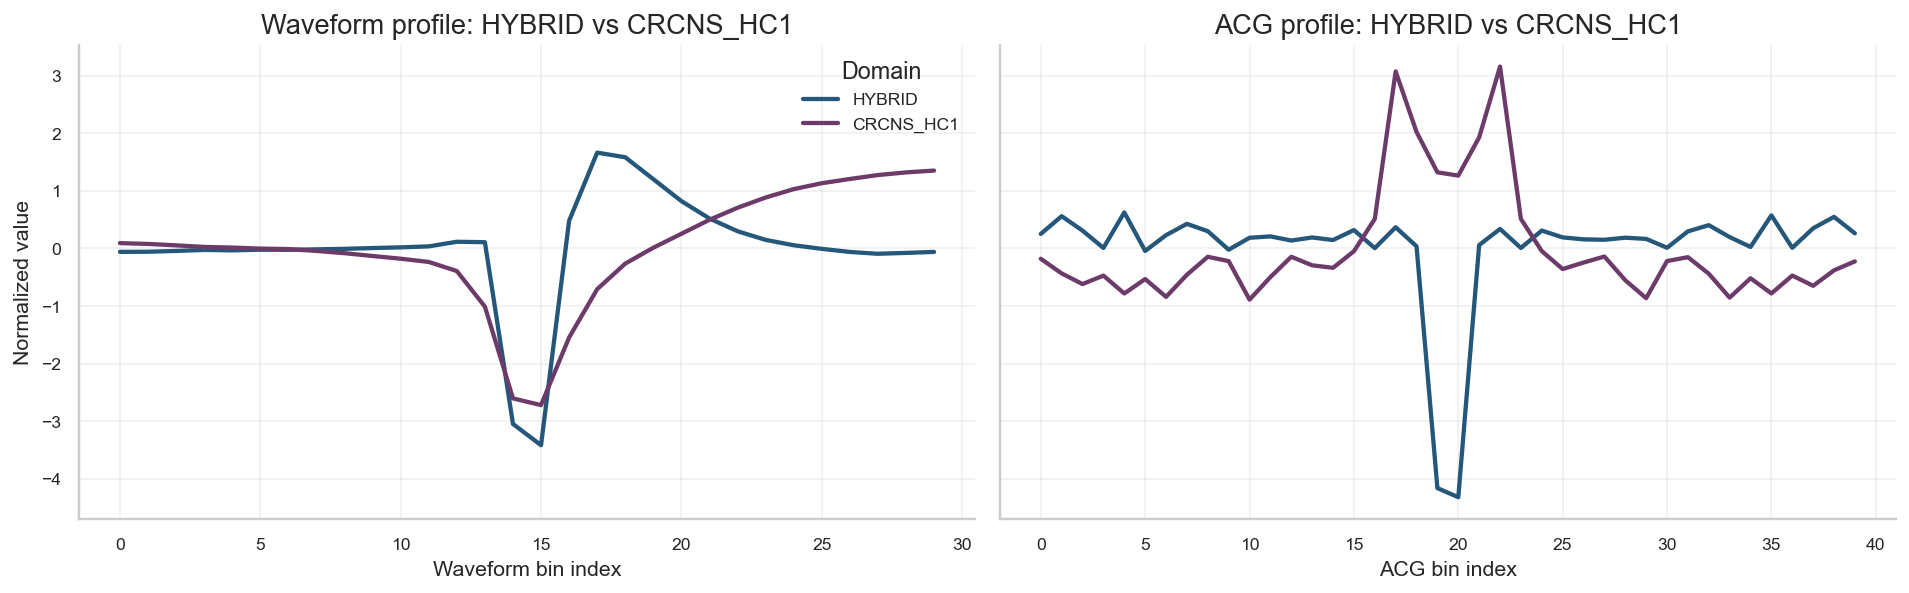

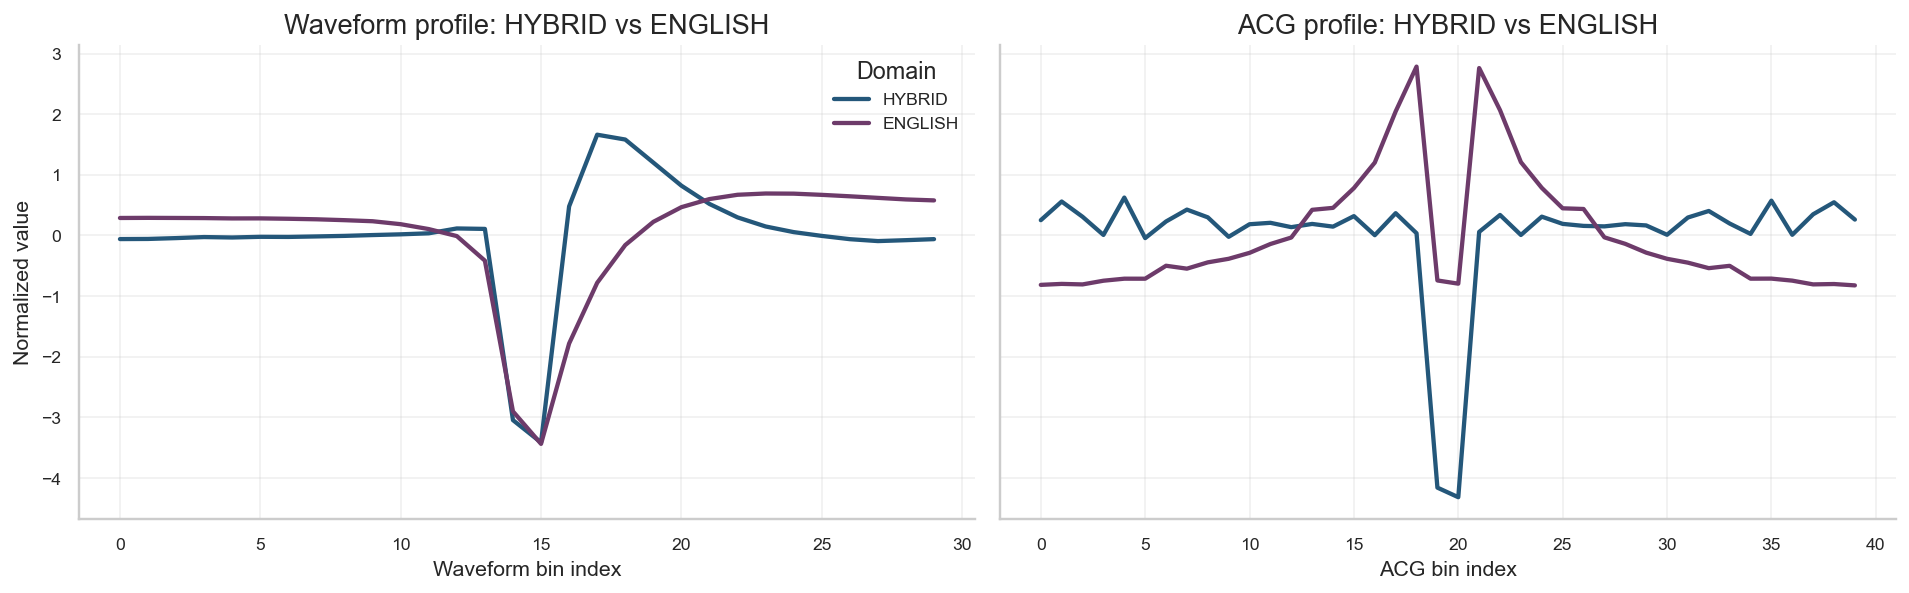

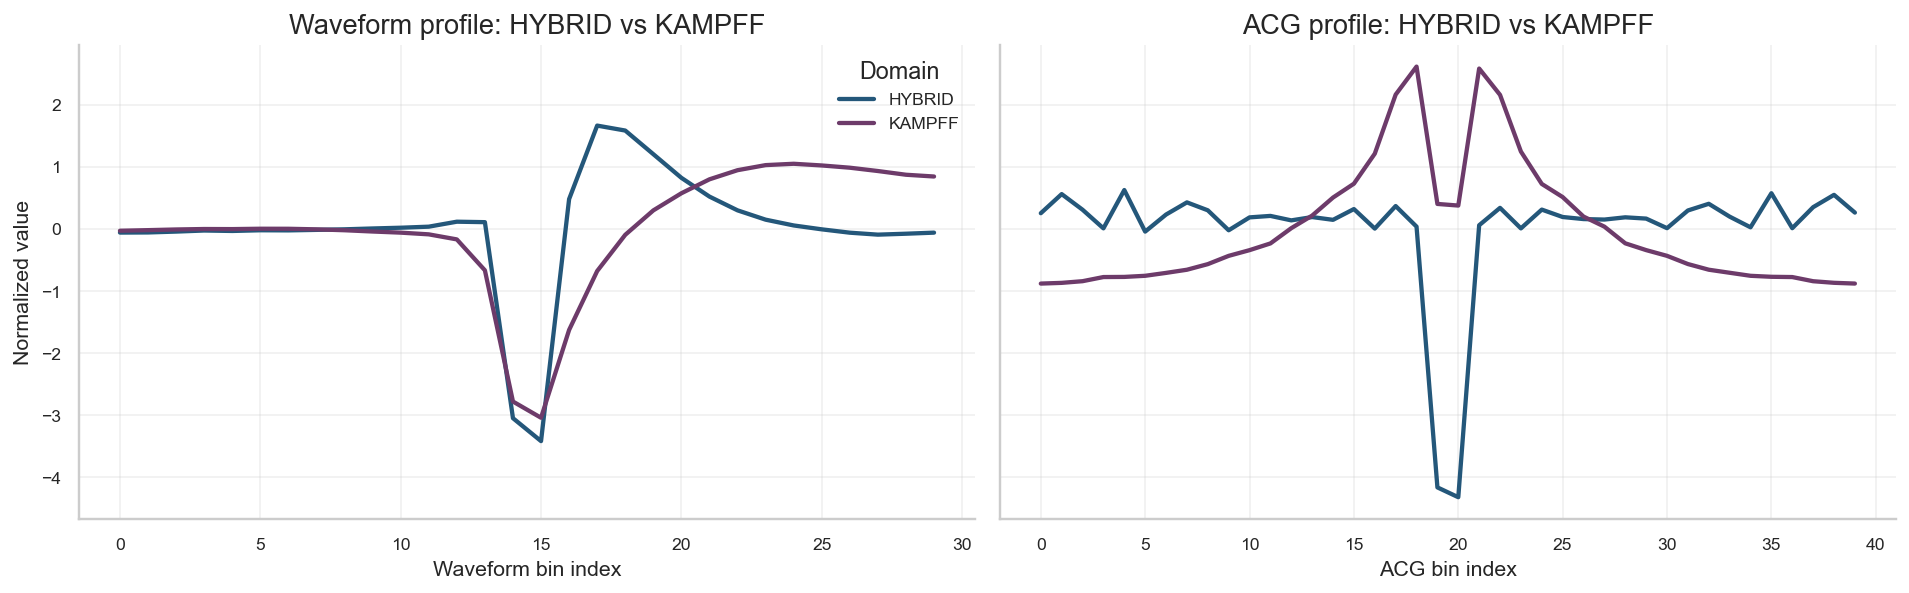

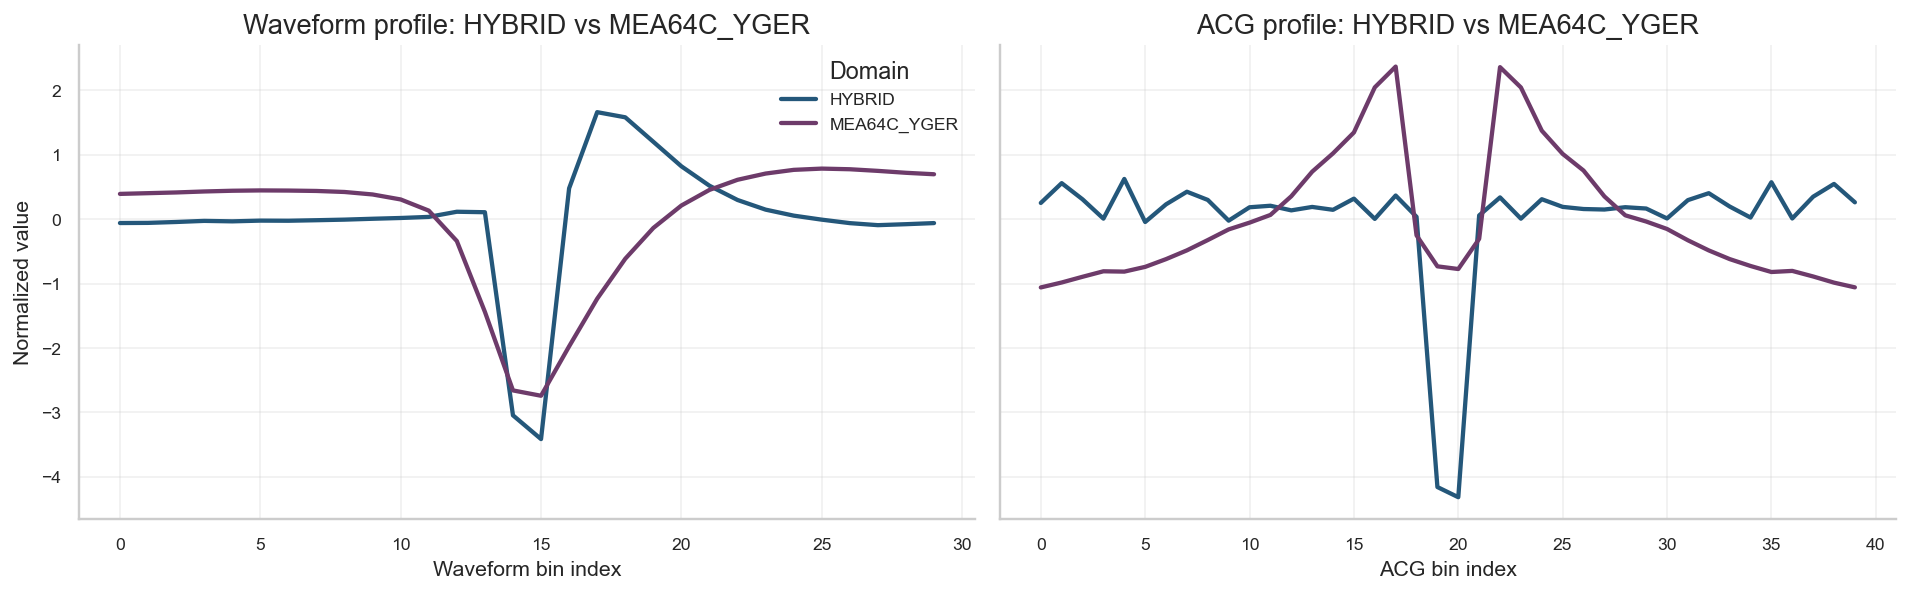

,family,rows,recordings
0,ENGLISH,3151,15
1,MEA64C_YGER,2997,4
2,KAMPFF,1743,4
3,BOYDEN,907,4
4,CRCNS_HC1,184,4


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/01_data_extraction_and_audit/family_profile_summary.csv')

In [44]:
paired_families = sorted(df.loc[df["dataset_kind"].eq("paired"), "paired_family"].dropna().unique())
hybrid_df = df[df["dataset_kind"].eq("hybrid")].copy()

family_profile_rows = []
for family_name in paired_families:
    family_df = df[df["paired_family"].eq(family_name)].copy()

    wf_hybrid = hybrid_df[waveform_bin_cols].mean()
    wf_family = family_df[waveform_bin_cols].mean()
    acg_hybrid = hybrid_df[acg_cols].mean()
    acg_family = family_df[acg_cols].mean()

    wf_plot = pd.DataFrame({
        "bin_idx": [int(c.split("_")[-1]) for c in waveform_bin_cols],
        "HYBRID": wf_hybrid.values,
        family_name: wf_family.values,
    }).sort_values("bin_idx")
    acg_plot = pd.DataFrame({
        "bin_idx": [int(c.split("_")[-1]) for c in acg_cols],
        "HYBRID": acg_hybrid.values,
        family_name: acg_family.values,
    }).sort_values("bin_idx")

    # Normalize each curve to emphasize shape over absolute scale.
    wf_plot[["HYBRID", family_name]] = (wf_plot[["HYBRID", family_name]] - wf_plot[["HYBRID", family_name]].mean()) / (wf_plot[["HYBRID", family_name]].std() + 1e-9)
    acg_plot[["HYBRID", family_name]] = (acg_plot[["HYBRID", family_name]] - acg_plot[["HYBRID", family_name]].mean()) / (acg_plot[["HYBRID", family_name]].std() + 1e-9)

    wf_long = wf_plot.melt(id_vars="bin_idx", var_name="domain", value_name="value")
    acg_long = acg_plot.melt(id_vars="bin_idx", var_name="domain", value_name="value")

    fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.4), sharey=True)
    sns.lineplot(
        data=wf_long,
        x="bin_idx",
        y="value",
        hue="domain",
        palette={"HYBRID": PALETTE["hybrid"], family_name: PALETTE["accent"]},
        linewidth=2.2,
        ax=axes[0],
    )
    axes[0].set_title(f"Waveform profile: HYBRID vs {family_name}")
    axes[0].set_xlabel("Waveform bin index")
    axes[0].set_ylabel("Normalized value")

    sns.lineplot(
        data=acg_long,
        x="bin_idx",
        y="value",
        hue="domain",
        palette={"HYBRID": PALETTE["hybrid"], family_name: PALETTE["accent"]},
        linewidth=2.2,
        ax=axes[1],
    )
    axes[1].set_title(f"ACG profile: HYBRID vs {family_name}")
    axes[1].set_xlabel("ACG bin index")
    axes[1].set_ylabel("")

    axes[0].legend(title="Domain", frameon=False)
    axes[1].legend([], [], frameon=False)
    fig.tight_layout()

    safe_family = "".join(ch.lower() if ch.isalnum() else "_" for ch in family_name).strip("_")
    save_figure(fig, f"waveform_acg_profile_{safe_family}")
    plt.show()

    family_profile_rows.append({
        "family": family_name,
        "rows": len(family_df),
        "recordings": family_df["recording_key"].nunique(),
    })

family_profile_summary = pd.DataFrame(family_profile_rows).sort_values("rows", ascending=False).reset_index(drop=True)
display(family_profile_summary)
save_table(family_profile_summary, "family_profile_summary")


### Graph Interpretation: Per-Family Waveform + ACG Profiles

**What we learn**
- Each paired family has a distinct morphology shift relative to `HYBRID`; the direction and magnitude differ by family.
- Shift signatures are present in both waveform bins and ACG bins, but not in the same way for every family.
- BOYDEN exhibits a distinct ACG morphology around the refractory region (20) relative to HYBRID, suggesting family-specific temporal firing statistics and reinforcing the family-structured domain-shift hypothesis.

**How this sets up domain-shift hypotheses**
- Supports a **family-structured domain shift** rather than one global shift.
- Predicts that adaptation methods can win on some families and fail on others unless they are robust to family-specific manifolds.
- Justifies leave-one-family-out stress tests and per-family reporting later in the thesis.


**Paired labeled support counts by family/sorter**

sorter_name,HerdingSpikes2,IronClust,JRClust,KiloSort,KiloSort2,Klusta,MountainSort4,SpykingCircus,Tridesclous
paired_family,,,,,,,,,
BOYDEN,0,7,6,5,9,3,4,6,3
CRCNS_HC1,0,2,2,3,2,3,3,4,3
ENGLISH,3,11,0,11,9,0,18,16,3
KAMPFF,5,4,2,3,5,0,6,5,5
MEA64C_YGER,8,4,2,4,3,2,4,5,4


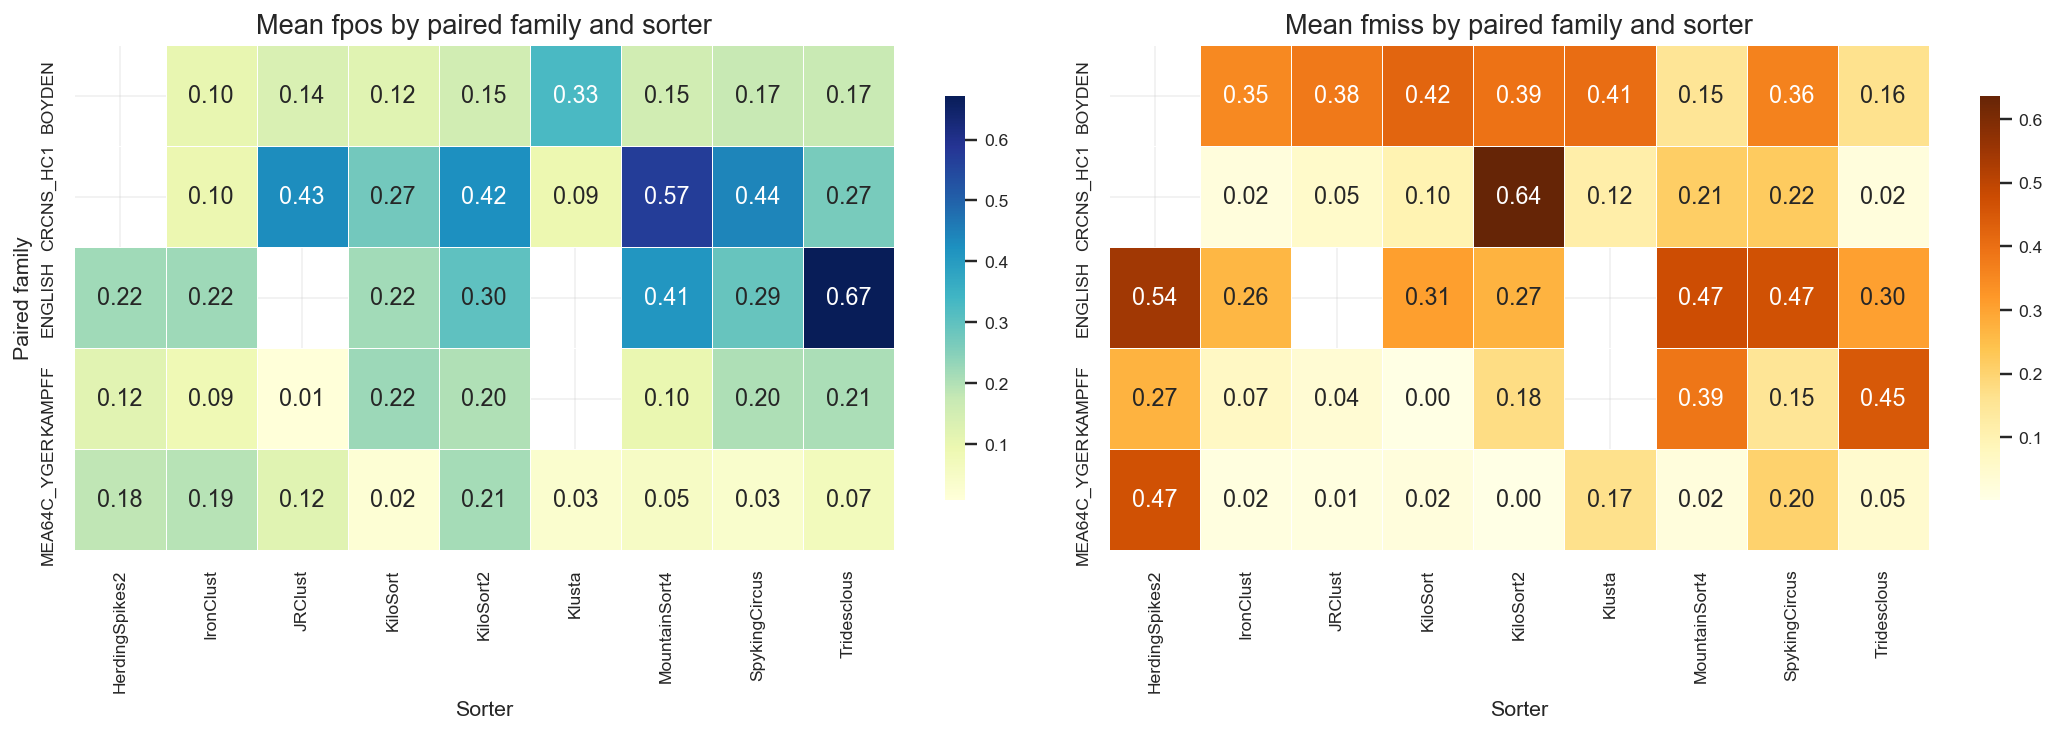

In [45]:
paired_only_labeled = df[df["is_paired_labeled"]].copy()

fpos_family_sorter = paired_only_labeled.pivot_table(
    index="paired_family", columns="sorter_name", values="fpos", aggfunc="mean"
).sort_index()

fmiss_family_sorter = paired_only_labeled.pivot_table(
    index="paired_family", columns="sorter_name", values="fmiss", aggfunc="mean"
).sort_index()

support_counts = paired_only_labeled.pivot_table(
    index="paired_family", columns="sorter_name", values="row_uid", aggfunc="size", fill_value=0
).sort_index()

display(Markdown("**Paired labeled support counts by family/sorter**"))
display(support_counts)
save_table(support_counts.reset_index(), "paired_labeled_support_by_family_sorter")

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))
sns.heatmap(fpos_family_sorter, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Mean fpos by paired family and sorter")
axes[0].set_xlabel("Sorter")
axes[0].set_ylabel("Paired family")

sns.heatmap(fmiss_family_sorter, cmap="YlOrBr", annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title("Mean fmiss by paired family and sorter")
axes[1].set_xlabel("Sorter")
axes[1].set_ylabel("")

fig.tight_layout()
save_figure(fig, "family_sorter_target_heatmaps")
plt.show()


### Graph Interpretation: Family × Sorter Target Heatmaps

**What we learn**
- Target behavior varies jointly by paired family and sorter; performance-relevant structure is not uniform.
- Some family/sorter cells have sparse support, which increases uncertainty and instability risk.

**How this sets up domain-shift hypotheses**
- Supports an **interaction-shift hypothesis**: distribution shift is partly conditional on family and sorter, not just domain label.
- Motivates grouped evaluation and robustness checks beyond single aggregate metrics.


## 4. Structural Projection Of Hybrid vs Paired Domain

A compact PCA projection over waveform, ACG, amplitude, and QC features gives a high-level view of how strongly domains overlap in feature space.


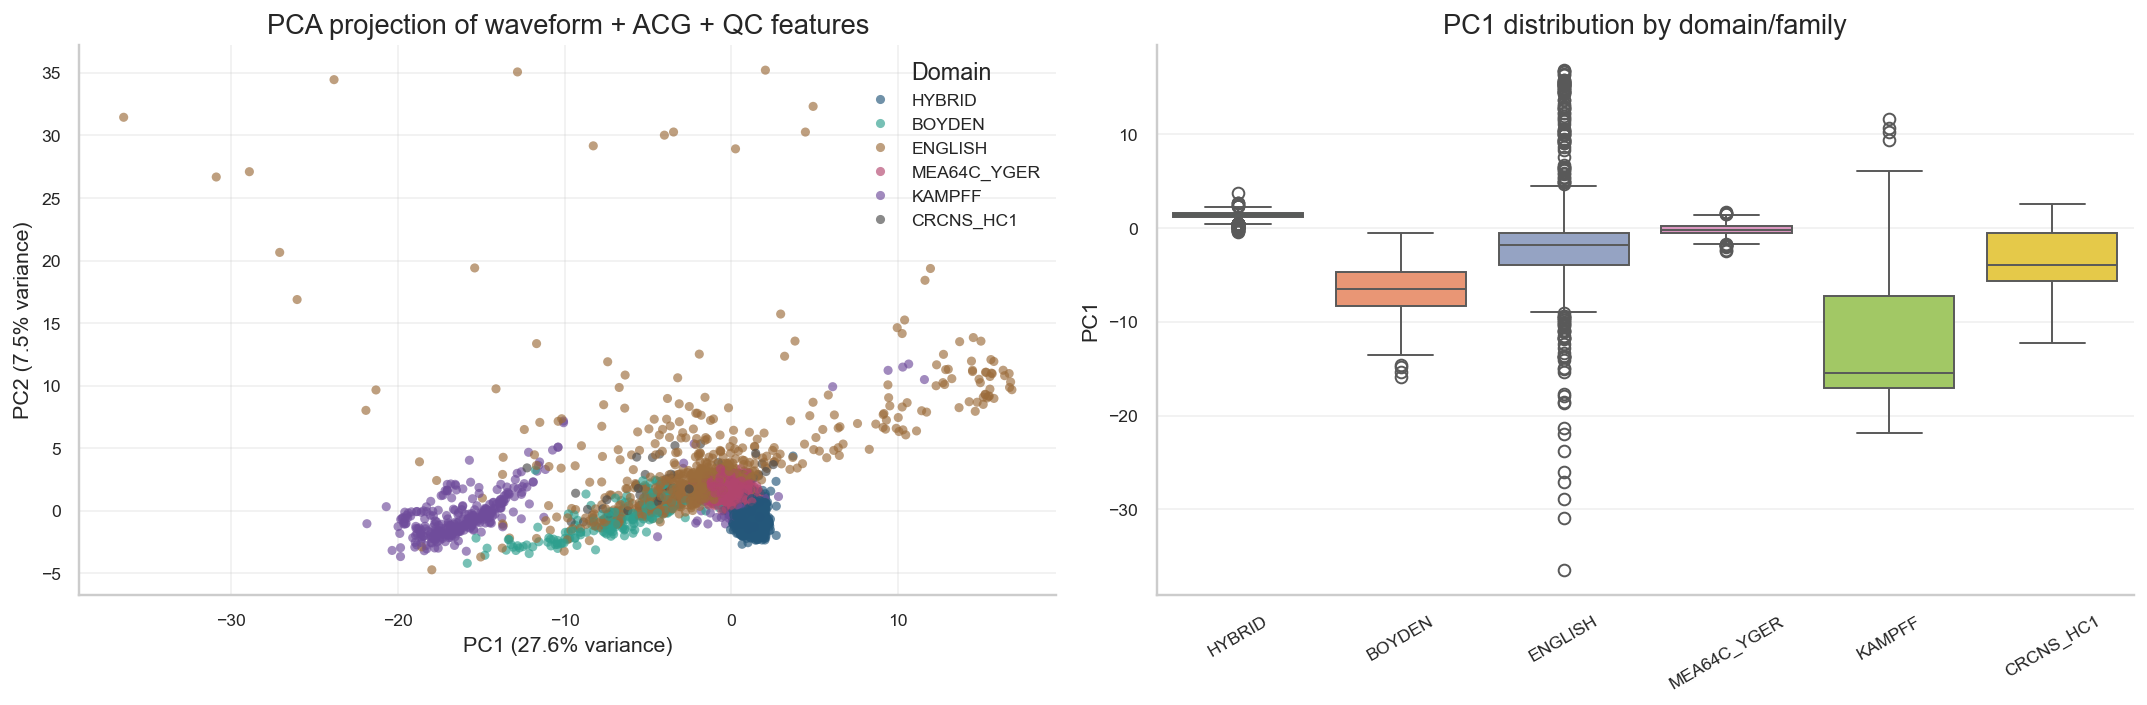

In [46]:
projection_features = []
for block in [waveform_bin_cols[:20], acg_cols[:20], amp_cols[:8], si_cols[:8], recording_cols]:
    projection_features.extend(block)
projection_features = [c for c in dict.fromkeys(projection_features) if c in df.columns]

sample_n = min(8000, len(df))
sample_df = df.sample(n=sample_n, random_state=42).copy()

X = sample_df[projection_features].copy()
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

projection = pd.DataFrame({
    "pc1": pcs[:, 0],
    "pc2": pcs[:, 1],
    "dataset_kind": sample_df["dataset_kind"].to_numpy(),
    "paired_family": sample_df["paired_family"].to_numpy(),
})
projection["domain_group"] = np.where(projection["dataset_kind"].eq("hybrid"), "HYBRID", projection["paired_family"])

family_order = ["HYBRID", "BOYDEN", "ENGLISH", "KAMPFF", "MEA64C_YGER", "CRCNS_HC1"]
projection = projection[projection["domain_group"].isin(family_order)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

sns.scatterplot(
    data=projection,
    x="pc1",
    y="pc2",
    hue="domain_group",
    palette={
        "HYBRID": PALETTE["hybrid"],
        "BOYDEN": "#2E9F8E",
        "ENGLISH": "#9B6C3B",
        "KAMPFF": "#6F4C9B",
        "MEA64C_YGER": "#B2456E",
        "CRCNS_HC1": "#4A4A4A",
    },
    s=22,
    alpha=0.65,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("PCA projection of waveform + ACG + QC features")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[0].legend(title="Domain", frameon=False, loc="upper right")

sns.boxplot(data=projection, x="domain_group", y="pc1", hue="domain_group", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("PC1 distribution by domain/family")
axes[1].set_xlabel("")
axes[1].set_ylabel("PC1")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
save_figure(fig, "domain_projection_pca")
plt.show()


### Graph Interpretation: PCA Domain Projection

**What we learn**
- Hybrid and paired observations are not perfectly overlapping in low-dimensional structure; families occupy different regions and spreads.
- PC1 spread differences indicate systematic geometry changes across domains/families.

**How this sets up domain-shift hypotheses**
- Supports a **representation-geometry shift hypothesis**: source and target manifolds are displaced/reshaped.
- Justifies manifold-aware transfer and shift-filtered stacking instead of plain pooled training.


## 5. Split Protocol Diagnostics

The main benchmark uses recording-disjoint holdout on paired-labeled rows. Stress analysis uses leave-one-family-out. The checks below make leakage boundaries explicit.


,protocol,train_rows,test_rows,train_recordings,test_recordings,recording_leakage
0,recording_disjoint_main,146,61,23,6,False


,held_out_family,train_rows,test_rows,train_recordings,test_recordings
0,ENGLISH,136,71,16,13
1,BOYDEN,164,43,25,4
2,MEA64C_YGER,171,36,25,4
3,KAMPFF,172,35,25,4
4,CRCNS_HC1,185,22,25,4


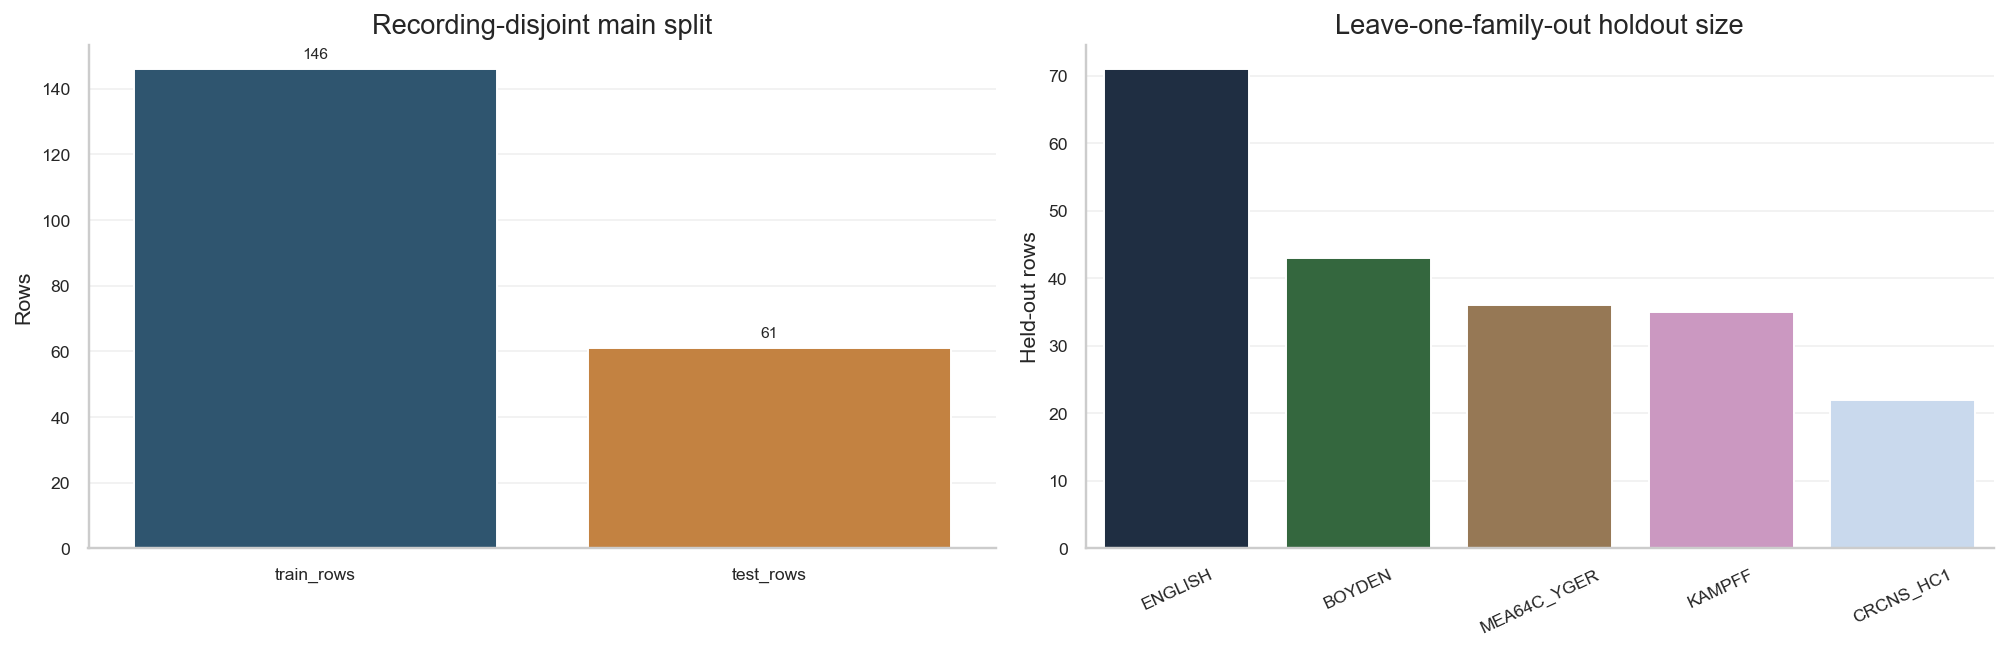

In [47]:
paired_labeled_df = df[df["is_paired_labeled"]].copy()

groups = paired_labeled_df["recording_key"].to_numpy()
splitter = GroupShuffleSplit(n_splits=64, test_size=0.2, random_state=42)

best_train_idx = None
best_test_idx = None
best_gap = float("inf")
for train_idx, test_idx in splitter.split(paired_labeled_df, groups=groups):
    gap = abs(len(test_idx) - 100)
    if gap < best_gap:
        best_gap = gap
        best_train_idx, best_test_idx = train_idx, test_idx

main_train = paired_labeled_df.iloc[best_train_idx].copy()
main_test = paired_labeled_df.iloc[best_test_idx].copy()
main_disjoint = set(main_train["recording_key"]).isdisjoint(set(main_test["recording_key"]))

protocol_summary = pd.DataFrame([
    {
        "protocol": "recording_disjoint_main",
        "train_rows": len(main_train),
        "test_rows": len(main_test),
        "train_recordings": main_train["recording_key"].nunique(),
        "test_recordings": main_test["recording_key"].nunique(),
        "recording_leakage": not main_disjoint,
    }
])

lofo_rows = []
for family_name in sorted(paired_labeled_df["paired_family"].dropna().unique()):
    holdout = paired_labeled_df[paired_labeled_df["paired_family"].eq(family_name)].copy()
    train = paired_labeled_df[~paired_labeled_df["paired_family"].eq(family_name)].copy()
    lofo_rows.append({
        "held_out_family": family_name,
        "train_rows": len(train),
        "test_rows": len(holdout),
        "train_recordings": train["recording_key"].nunique(),
        "test_recordings": holdout["recording_key"].nunique(),
    })
lofo_table = pd.DataFrame(lofo_rows).sort_values("test_rows", ascending=False).reset_index(drop=True)

display(protocol_summary)
display(lofo_table)
save_table(protocol_summary, "recording_disjoint_protocol_summary")
save_table(lofo_table, "family_held_out_protocol_summary")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

main_plot = protocol_summary.melt(
    id_vars=["protocol"],
    value_vars=["train_rows", "test_rows"],
    var_name="split",
    value_name="rows",
)
sns.barplot(data=main_plot, x="split", y="rows", hue="split", palette={"train_rows": PALETTE["hybrid"], "test_rows": PALETTE["paired_unlabeled"]}, legend=False, ax=axes[0])
axes[0].set_title("Recording-disjoint main split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
for patch in axes[0].patches:
    y = patch.get_height()
    axes[0].annotate(f"{int(y)}", (patch.get_x() + patch.get_width() / 2, y), ha="center", va="bottom", fontsize=8, xytext=(0, 4), textcoords="offset points")

sns.barplot(data=lofo_table, x="held_out_family", y="test_rows", hue="held_out_family", palette="cubehelix", legend=False, ax=axes[1])
axes[1].set_title("Leave-one-family-out holdout size")
axes[1].set_xlabel("")
axes[1].set_ylabel("Held-out rows")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
save_figure(fig, "split_protocol_diagnostics")
plt.show()


### Graph Interpretation: Split Protocol Diagnostics

**What we learn**
- The main benchmark split is recording-disjoint, so leakage through recording identity is blocked.
- Family-held-out fold sizes are uneven, confirming variable stress difficulty across families.

**How this sets up domain-shift hypotheses**
- Ensures later gains are attributable to transfer quality, not leakage artifacts.
- Establishes a two-level test of domain shift: recording-disjoint main benchmark + family-held-out robustness stress.


In [ ]:
fmiss_missing_rows = int(df["fmiss"].isna().sum())
fmiss_missing_unmatched = int((df["fmiss"].isna() & df["match_status"].eq("unmatched")).sum())
fmiss_missing_fp = int((df["fmiss"].isna() & df["match_status"].eq("false_positive")).sum())

display(Markdown(
    f"""
## Key takeaways

- The packaged dataset contains **33,206 rows rows** across **61 recordings** and **9 sorters**.
- Paired-labeled supervision remains extremely limited (**207 rows rows**), while the paired-unlabeled structural pool is much larger (**{int(df['is_paired_unlabeled'].sum()):,} rows**).
- `fmiss` has fewer usable labels (**{int(df['fmiss'].notna().sum()):,} available; {fmiss_missing_rows:,} missing**) mainly because rows without GT alignment cannot define miss-rate: `unmatched` (**{fmiss_missing_unmatched:,}**) and `false_positive` (**{fmiss_missing_fp:,}**) dominate the missing set.
- Feature distribution panels up front show domain-shift shape differences before modeling.
- Family-specific waveform/ACG figures make per-family structure explicit instead of overlaying everything in one chart.
- The selected main protocol is strictly recording-disjoint (`recording_leakage=False`) and therefore leakage-safe for final evaluation.
"""
))



## Key takeaways

- The packaged dataset contains **33,206 rows** across **61 recordings** and **9 sorters**.
- Paired-labeled supervision remains extremely limited (**207 rows**), while the paired-unlabeled structural pool is much larger (**8,775 rows**).
- `fmiss` has fewer usable labels (**18,660 available; 14,546 missing**) mainly because rows without GT alignment cannot define miss-rate: `unmatched` (**7,374**) and `false_positive` (**7,172**) dominate the missing set.
- Feature distribution panels up front show domain-shift shape differences before modeling.
- Family-specific waveform/ACG figures make per-family structure explicit instead of overlaying everything in one chart.
- The selected main protocol is strictly recording-disjoint (`recording_leakage=False`) and therefore leakage-safe for final evaluation.
